# Fig 2 — E1 vs E2 playhead-gap boxplot (with discontinuity zone)

Shows max |playhead gap| per switch event, naive (E1) vs aligned (E2),
across 4 filter delays. The 1 GOP threshold is the design envelope for
aligned switching — values above it represent perceived discontinuities;
below = continuous playback. Per-cell text annotations show how many of
the 5 runs landed in the discontinuity zone.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "figures"))

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from _data import load_aggregate
from _style import (
    COL_ALIGNED,
    COL_NAIVE,
    GOP_DURATION_MS,
    apply_acm_style,
    fig_one_col,
)

apply_acm_style()

In [2]:
e1 = load_aggregate("e1").assign(mode="naive")
e2 = load_aggregate("e2").assign(mode="aligned")
combined = pd.concat([e1, e2], ignore_index=True)
combined["offset_s"] = combined["cell_id"].str.extract(r"offset(\d+)").astype(int)

# Per-cell discontinuity count: a run is a "perceived discontinuity" if
# its max |playhead gap| exceeds the 1 GOP envelope.
def disc_count(df):
    return int((df["max_playhead_gap_ms"] > GOP_DURATION_MS).sum()), len(df)

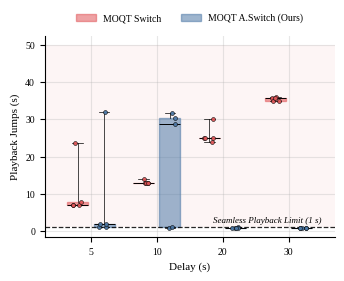

In [3]:
fig, ax = fig_one_col(height_in=2.7)

offsets = sorted(combined["offset_s"].unique())
positions_naive = [i - 0.20 for i in range(len(offsets))]
positions_aligned = [i + 0.20 for i in range(len(offsets))]

# Convert ms to seconds throughout for readability.
naive_data = [combined.query("mode == 'naive' and offset_s == @o")["max_playhead_gap_ms"].values / 1000.0 for o in offsets]
aligned_data = [combined.query("mode == 'aligned' and offset_s == @o")["max_playhead_gap_ms"].values / 1000.0 for o in offsets]

GOP_DURATION_S = GOP_DURATION_MS / 1000.0  # 1 s

# Shaded "discontinuity zone" above 1 GOP (drawn first so dots/boxes overlay it).
ax.axhspan(GOP_DURATION_S, 50, facecolor=COL_NAIVE, alpha=0.06, zorder=0)

bp_n = ax.boxplot(
    naive_data, positions=positions_naive, widths=0.32, patch_artist=True,
    medianprops={"color": "black", "linewidth": 0.7},
    whiskerprops={"linewidth": 0.5}, capprops={"linewidth": 0.5},
    flierprops={"marker": "", "markersize": 0},
    whis=(0, 100),
)
bp_a = ax.boxplot(
    aligned_data, positions=positions_aligned, widths=0.32, patch_artist=True,
    medianprops={"color": "black", "linewidth": 0.7},
    whiskerprops={"linewidth": 0.5}, capprops={"linewidth": 0.5},
    flierprops={"marker": "", "markersize": 0},
    whis=(0, 100),
)
for patch in bp_n["boxes"]:
    patch.set_facecolor(COL_NAIVE)
    patch.set_edgecolor(COL_NAIVE)
    patch.set_alpha(0.55)
for patch in bp_a["boxes"]:
    patch.set_facecolor(COL_ALIGNED)
    patch.set_edgecolor(COL_ALIGNED)
    patch.set_alpha(0.55)

# Individual run scatter dots.
rng = np.random.default_rng(seed=0)
for pos, vals in zip(positions_naive, naive_data):
    jitter = rng.uniform(-0.08, 0.08, size=len(vals))
    ax.scatter(pos + jitter, vals, s=8, color=COL_NAIVE,
               edgecolor="black", linewidth=0.4, zorder=3, alpha=0.95)
for pos, vals in zip(positions_aligned, aligned_data):
    jitter = rng.uniform(-0.08, 0.08, size=len(vals))
    ax.scatter(pos + jitter, vals, s=8, color=COL_ALIGNED,
               edgecolor="black", linewidth=0.4, zorder=3, alpha=0.95)

ax.set_xticks(range(len(offsets)))
ax.set_xticklabels([f"{o}" for o in offsets])
ax.set_xlabel("Delay (s)")
ax.set_ylabel("Playback Jumps (s)")

ax.axhline(GOP_DURATION_S, color="black", linestyle="--", linewidth=0.9, alpha=0.85)
ax.text(len(offsets) - 0.5, GOP_DURATION_S + 0.7,
        "Seamless Playback Limit (1 s)",
        fontsize=6.5, ha="right", va="bottom", style="italic")

ax.legend(handles=[
    mpatches.Patch(facecolor=COL_NAIVE, alpha=0.55, edgecolor=COL_NAIVE, label="MOQT Switch"),
    mpatches.Patch(facecolor=COL_ALIGNED, alpha=0.55, edgecolor=COL_ALIGNED, label="MOQT A.Switch (Ours)"),
], loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=False, fontsize=7)

In [4]:
fig.savefig(Path.cwd().parent / "figures" / "fig2_e1_e2_playhead_gap.pdf")
fig.savefig(Path.cwd().parent / "figures" / "fig2_e1_e2_playhead_gap.png", dpi=200)